# This Notebook is used to create a visual representation of the edge transoforms from the pose graph.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image
import os

In [2]:
graph_poses=[]
graph_from_ids=[]
graph_to_ids=[]
graph_edge_types=[]
folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/edge_results'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
file_count =int((file_count-1))
print(f"Number of files: {file_count}")
for i in range(0,file_count,1):
    filename = filename=folder_path+f"/edge_{i:04d}.txt"
    matrix = []
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.startswith('from_vertex_id'):
                # Extract the vertex ID from the line
                from_vertex_id = int(line.split(':')[1].strip())
                # print(f"From Vertex ID: {from_vertex_id}")
                graph_from_ids.append(from_vertex_id)
            elif line.startswith('to_vertex_id'):
                # Extract the vertex ID from the line
                to_vertex_id = int(line.split(':')[1].strip())
                # print(f"To Vertex ID: {to_vertex_id}")
                graph_to_ids.append(to_vertex_id)
            elif line.startswith('edge_type'):
                # Extract the vertex ID from the line
                edge_type = int(line.split(':')[1].strip())
                # print(f"To Vertex ID: {to_vertex_id}")
                graph_edge_types.append(edge_type)
            elif line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)

    temp = np.array(matrix[0:4])
    graph_poses.append(np.array(matrix[0:4]))
#poses=np.array(poses)

Number of files: 294


In [3]:
poses=[]
from_ids=[]
to_ids=[]
edge_types=[]

for i in range(0,graph_from_ids.__len__(),1):
    print(f"From Vertex ID: {graph_from_ids[i]}, To Vertex ID: {graph_to_ids[i]}")
    print(f"Pose: {graph_poses[i]}")
    print("")
    if graph_edge_types[i] == 0 and graph_from_ids[i]<1000000:
        from_ids.append(graph_from_ids[i])
        to_ids.append(graph_to_ids[i])
        edge_types.append(graph_edge_types[i])
        poses.append(graph_poses[i])

From Vertex ID: 63, To Vertex ID: 64
Pose: [[ 9.99792e-01  4.78194e-04  2.03916e-02 -1.66370e-01]
 [-5.49163e-04  9.99994e-01  3.47484e-03 -9.91573e-04]
 [-2.03898e-02 -3.48532e-03  9.99786e-01  2.82901e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]

From Vertex ID: 191, To Vertex ID: 192
Pose: [[ 0.999841    0.00525212 -0.0170692  -0.145073  ]
 [-0.00522352  0.999985    0.00171954 -0.00599799]
 [ 0.017078   -0.00163011  0.999853   -0.00626106]
 [ 0.          0.          0.          1.        ]]

From Vertex ID: 271, To Vertex ID: 272
Pose: [[ 9.99988e-01  1.95640e-03  4.43614e-03 -1.19911e-01]
 [-1.92178e-03  9.99968e-01 -7.79580e-03 -2.60088e-04]
 [-4.45125e-03  7.78719e-03  9.99960e-01  7.38196e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]

From Vertex ID: 111, To Vertex ID: 112
Pose: [[ 9.99974e-01  2.75347e-04 -7.14986e-03 -2.24181e-01]
 [-3.20649e-04  9.99980e-01 -6.33564e-03 -2.14546e-03]
 [ 7.14797e-03  6.33777e-03  9.99954e-01  7.47265e-03]
 [ 0.00

In [4]:
def bubble_sort(arr1, arr2, arr3):
    for i in range(len(arr1)):
        # Last i elements are already in place
        for j in range(0, len(arr1) - i - 1):
            if arr1[j] > arr1[j + 1]:
                # Swap if elements are in the wrong order
                arr1[j], arr1[j + 1] = arr1[j + 1], arr1[j]
                arr2[j], arr2[j + 1] = arr2[j + 1], arr2[j]
                arr3[j], arr3[j + 1] = arr3[j + 1], arr3[j]
    return np.array(arr1), np.array(arr2), np.array(arr3)

# Example usage:
my_list = [5, 2, 9, 1, 5, 6]
sorted_from, sorted_to, sorted_poses = bubble_sort(from_ids.copy(), to_ids.copy(), poses.copy())
print("Sorted list:", sorted_from)
print("Corresponding to list:", sorted_to)

Sorted list: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 2

In [5]:
# creating new matrices:
new_poses = []
pose1 = np.array([
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
new_poses.append(pose1)
for i in range(0,sorted_from.__len__(),1):
    temp_pose =  new_poses[i] @ sorted_poses[i] 
    new_poses.append(temp_pose)
print(new_poses[0])
new_poses = np.array(new_poses)

[[-1  0  0  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 0  0  0  1]]


In [6]:
origins = new_poses[:, :3, -1]
print(origins[0:3])
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in new_poses])
x= origins[..., 0].flatten()
y= origins[..., 1].flatten()
z= origins[..., 2].flatten()
#print(np.array(x))
# print(type(x))

[[ 0.          0.          0.        ]
 [ 0.162749   -0.00860072  0.0033146 ]
 [ 0.28730808 -0.0167051   0.01177674]]


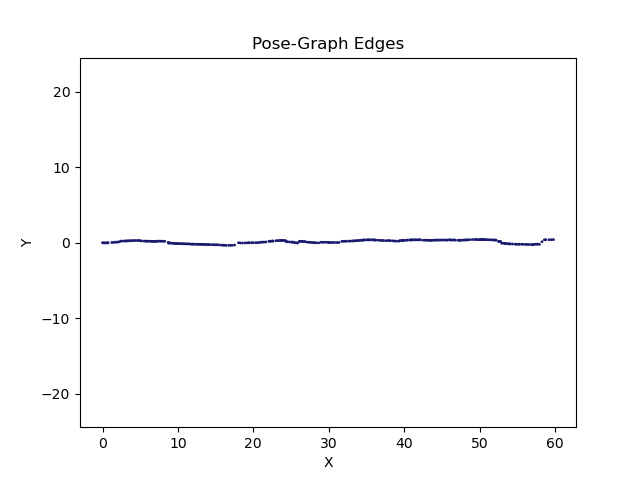

In [10]:
%matplotlib ipympl
s = np.ones(len(x))
#plt.scatter(x=x, y=y, color='red')
plt.scatter(x, y, s=s, color='midnightblue', label='Group 1')
# plt.xlim(0, 35)   
# plt.ylim(-7, 1) 
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Pose-Graph Edges")
plt.axis('equal')
plt.show()

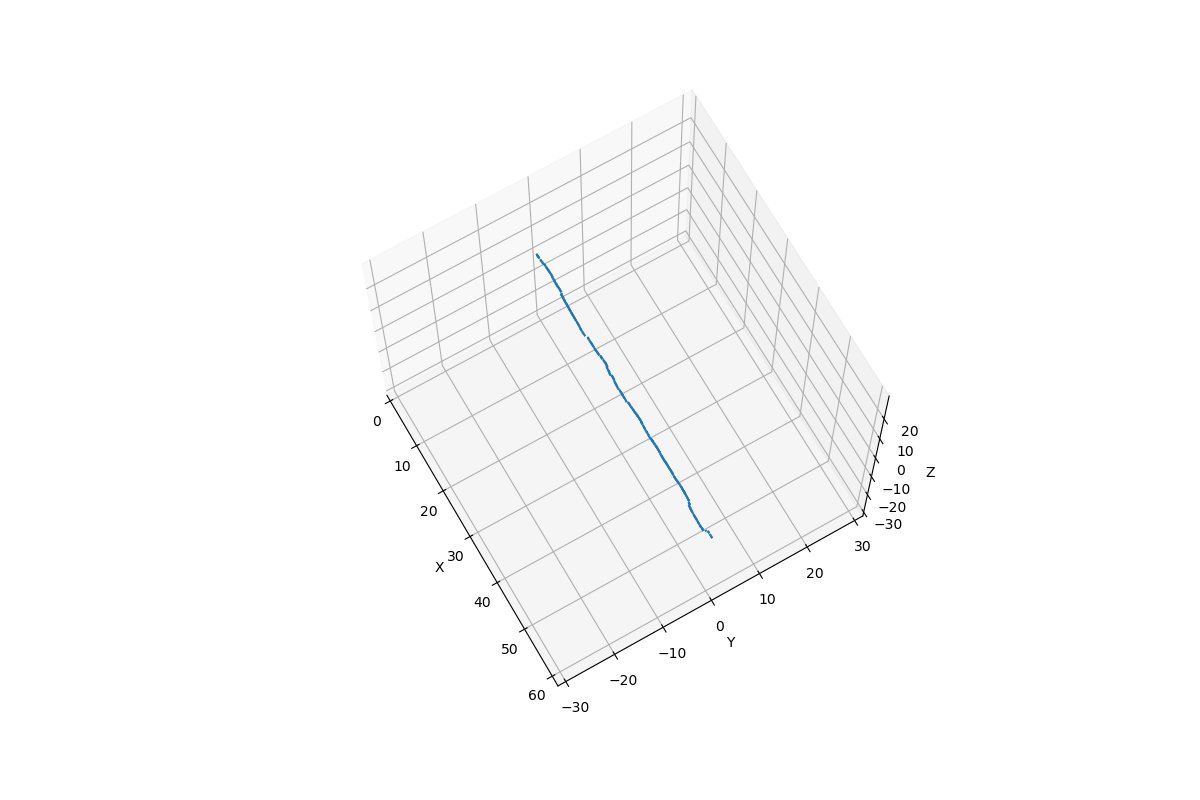

In [13]:
%matplotlib ipympl

all_points = np.concatenate([
    origins.reshape(-1, 3),
    (origins - dirs).reshape(-1, 3)  # quiver tip positions
], axis=0)

x_min, x_max = np.min(all_points[:, 0]), np.max(all_points[:, 0])
y_min, y_max = np.min(all_points[:, 1]), np.max(all_points[:, 1])
z_min, z_max = np.min(all_points[:, 2]), np.max(all_points[:, 2])

# Find the overall center and max range
max_range = max(x_max - x_min, y_max - y_min, z_max - z_min) / 2.0
x_mid = (x_max + x_min) / 2.0
y_mid = (y_max + y_min) / 2.0
z_mid = (z_max + z_min) / 2.0


# print(origins)
ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  -dirs[..., 0].flatten(),
  -dirs[..., 1].flatten(),
  -dirs[..., 2].flatten(), length=0.3, normalize=False)
ax.set_box_aspect([1,1,1])


ax.set_xlim(x_mid - max_range, x_mid + max_range)
ax.set_ylim(y_mid - max_range, y_mid + max_range)
ax.set_zlim(z_mid - max_range, z_mid + max_range)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(70, -30) 
plt.show()

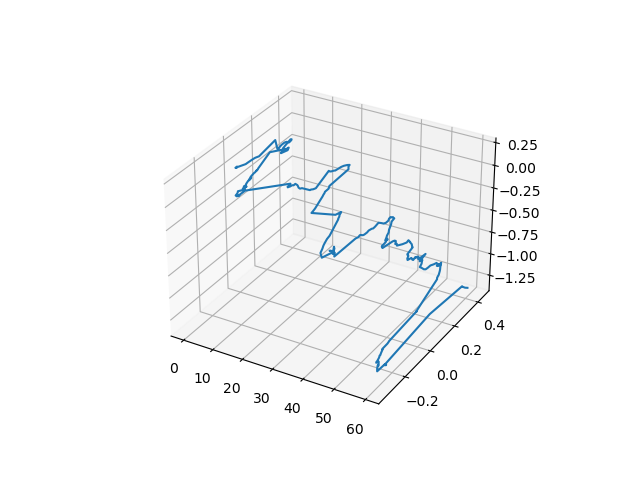

In [12]:
%matplotlib ipympl
ax = plt.axes(projection='3d')
ax.plot3D(x, y, z)